 ### FEMA - Feature Engineering

- Goal:
- Transform clean declarations, public assistance, and disaster summaries
- into modelling-ready features for disaster recovery cost prediction.



### STEP 1 - Setup

In [1]:

# import libraries

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)

DATA_PROCESSED = os.path.join("..", "data", "processed")

declarations = pd.read_csv(os.path.join(DATA_PROCESSED, "declarations_clean.csv"))
pa = pd.read_csv(os.path.join(DATA_PROCESSED, "public_assistance_clean.csv"))
summaries = pd.read_csv(os.path.join(DATA_PROCESSED, "disaster_summaries_clean.csv"))

# Convert dates
date_cols = ["declarationdate", "incidentbegindate", "incidentenddate"]

for col in date_cols:
    if col in declarations.columns:
        declarations[col] = pd.to_datetime(declarations[col], errors="coerce")

# Reference year
declarations["fydeclared"] = declarations["fydeclared"].fillna(
    declarations["declarationdate"].dt.year
)

In [2]:
# Step 1a - Base Disaster Features

base = declarations[[
    "disasternumber",
    "state",
    "declarationtype",
    "incidenttype",
    "fydeclared",
    "designatedarea",
    "declarationdate",
    "incidentbegindate",
    "incidentenddate"
]].copy()

base = base.drop_duplicates(subset=["disasternumber"])

base.head()

,disasternumber,state,declarationtype,incidenttype,fydeclared,designatedarea,declarationdate,incidentbegindate,incidentenddate
0,3610,Pr,Em,Severe Storm,2024,Adjuntas (Municipio),2024-08-13 00:00:00+00:00,2024-08-13 00:00:00+00:00,2024-08-16 00:00:00+00:00
1,5529,Or,Fm,Fire,2024,Washington (County),2024-08-09 00:00:00+00:00,2024-08-08 00:00:00+00:00,NaT
2,5528,Or,Fm,Fire,2024,Jefferson (County),2024-08-06 00:00:00+00:00,2024-08-04 00:00:00+00:00,NaT
3,5527,Or,Fm,Fire,2024,Deschutes (County),2024-08-02 00:00:00+00:00,2024-08-02 00:00:00+00:00,NaT
6,4312,Ca,Dr,Severe Storm,2017,Resighini Rancheria (Indian Reservation),2017-05-02 00:00:00+00:00,2017-02-08 00:00:00+00:00,2017-02-11 00:00:00+00:00


In [3]:
# Step 1b - Temporal Disaster Features

base["disaster_duration_days"] = (
    base["incidentenddate"] - base["incidentbegindate"]
).dt.days

base["declaration_delay_days"] = (
    base["declarationdate"] - base["incidentbegindate"]
).dt.days

# Clean negative values
base["disaster_duration_days"] = base["disaster_duration_days"].clip(lower=0)
base["declaration_delay_days"] = base["declaration_delay_days"].clip(lower=0)

base["declaration_year"] = base["declarationdate"].dt.year
base["declaration_month"] = base["declarationdate"].dt.month
base["declaration_quarter"] = base["declarationdate"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

base["declaration_season"] = base["declaration_month"].apply(get_season)

#### Step 2 - Public Assistance Aggregation Features

In [4]:

pa_features = (
    pa.groupby("disasternumber")
    .agg(
        pa_project_count=("projectamount", "count"),
        pa_project_amount_total=("projectamount", "sum"),
        pa_project_amount_mean=("projectamount", "mean"),
        pa_project_amount_median=("projectamount", "median"),
        pa_project_amount_max=("projectamount", "max"),
        pa_project_amount_std=("projectamount", "std"),
        pa_obligated_total=("federalshareobligated", "sum"),
        pa_obligated_mean=("federalshareobligated", "mean"),
        pa_obligated_max=("federalshareobligated", "max"),
        
        
    )
    .reset_index()
)

pa_features = pa_features.fillna(0)

pa_features["large_project_count"] = (
    pa[pa["projectamount"] >= pa["projectamount"].quantile(0.75)]
    .groupby("disasternumber")
    .size()
).reindex(pa_features["disasternumber"]).fillna(0).values

pa_features["small_project_count"] = (
    pa[pa["projectamount"] <= pa["projectamount"].quantile(0.25)]
    .groupby("disasternumber")
    .size()
).reindex(pa_features["disasternumber"]).fillna(0).values

#### Step 3 - Ratio and Interaction Features

In [5]:

pa_features["avg_obligation_per_project"] = (
    pa_features["pa_obligated_total"] / (pa_features["pa_project_count"] + 1)
)

pa_features["funding_intensity"] = (
    pa_features["pa_obligated_total"] / (pa_features["pa_project_amount_total"] + 1)
)

pa_features["large_project_ratio"] = (
    pa_features["large_project_count"] / (pa_features["pa_project_count"] + 1)
)

pa_features["small_project_ratio"] = (
    pa_features["small_project_count"] / (pa_features["pa_project_count"] + 1)
)

#### Step 4 - Disaster Summary Target

In [6]:
summaries.head()

,disasternumber,totalnumberiaapproved,totalamountihpapproved,totalamounthaapproved,totalamountonaapproved,totalobligatedamountpa,totalobligatedamountcatab,totalobligatedamountcatc2g,totalobligatedamounthmgp,paloaddate,ialoaddate
0,3601,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,NaN,NaN
1,3602,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,NaN,NaN
2,1802,0.0,0.0,0.0,0.0,1.881275e+07,1.342309e+07,4.869890e+06,2710679.0,2026-02-06 00:00:00+00:00,NaN
3,1292,0.0,0.0,0.0,0.0,2.981058e+08,1.436027e+08,1.504852e+08,67665966.0,2026-02-06 00:00:00+00:00,NaN
4,3163,0.0,0.0,0.0,0.0,5.380816e+06,5.369404e+06,0.000000e+00,0.0,2026-02-06 00:00:00+00:00,NaN


In [7]:
summary_features = (
    pa.groupby("disasternumber")
    .agg(
        totalobligated=("totalobligated", "sum")
    )
    .reset_index()
)

summary_features["log_totalobligated"] = np.log1p(
    summary_features["totalobligated"]
)

#### Step 5 - FEMA DSF Score

In [8]:
dsf = pa_features[[
    "disasternumber",
    "pa_project_count",
    "pa_project_amount_total",
    "pa_obligated_total"
]].copy()

dsf["dsf_scale_score"] = pd.qcut(
    dsf["pa_project_count"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

dsf["dsf_project_amount_score"] = pd.qcut(
    dsf["pa_project_amount_total"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

dsf["dsf_funding_score"] = pd.qcut(
    dsf["pa_obligated_total"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

dsf["dsf_combined_score"] = (
    dsf["dsf_scale_score"] +
    dsf["dsf_project_amount_score"] +
    dsf["dsf_funding_score"]
) / 3

dsf["dsf_combined_score"] = dsf["dsf_combined_score"].round()

#### Step 6 - Merge FEMA Features

In [9]:

features_fema = (
    base
    .merge(pa_features, on="disasternumber", how="left")
    .merge(dsf[[
        "disasternumber",
        "dsf_scale_score",
        "dsf_project_amount_score",
        "dsf_funding_score",
        "dsf_combined_score"
    ]], on="disasternumber", how="left")
    .merge(summary_features, on="disasternumber", how="left")
)

features_fema = features_fema.fillna(0)

print(f"Feature matrix: {features_fema.shape[0]:,} disasters x {features_fema.shape[1]} columns")
print(f"Null count: {features_fema.isnull().sum().sum()}")

Feature matrix: 5,184 disasters x 36 columns
Null count: 0


#### Step 8 - Correlation Signal Check

In [10]:

target = "log_totalobligated"

numeric_corr_df = features_fema.select_dtypes(
    include=["int64", "float64", "bool"]
)

corr = (
    numeric_corr_df
    .corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

corr.head(20)

funding_intensity             0.985296
dsf_combined_score            0.929805
dsf_funding_score             0.921981
dsf_project_amount_score      0.921947
dsf_scale_score               0.905279
large_project_ratio           0.801238
small_project_ratio           0.732863
pa_project_count              0.427602
fydeclared                    0.394355
small_project_count           0.369019
large_project_count           0.335670
pa_project_amount_mean        0.306842
avg_obligation_per_project    0.290355
pa_obligated_mean             0.289490
declaration_delay_days        0.285410
disasternumber                0.226218
pa_project_amount_std         0.191666
pa_project_amount_total       0.150552
totalobligated                0.148736
pa_obligated_total            0.148597
Name: log_totalobligated, dtype: float64

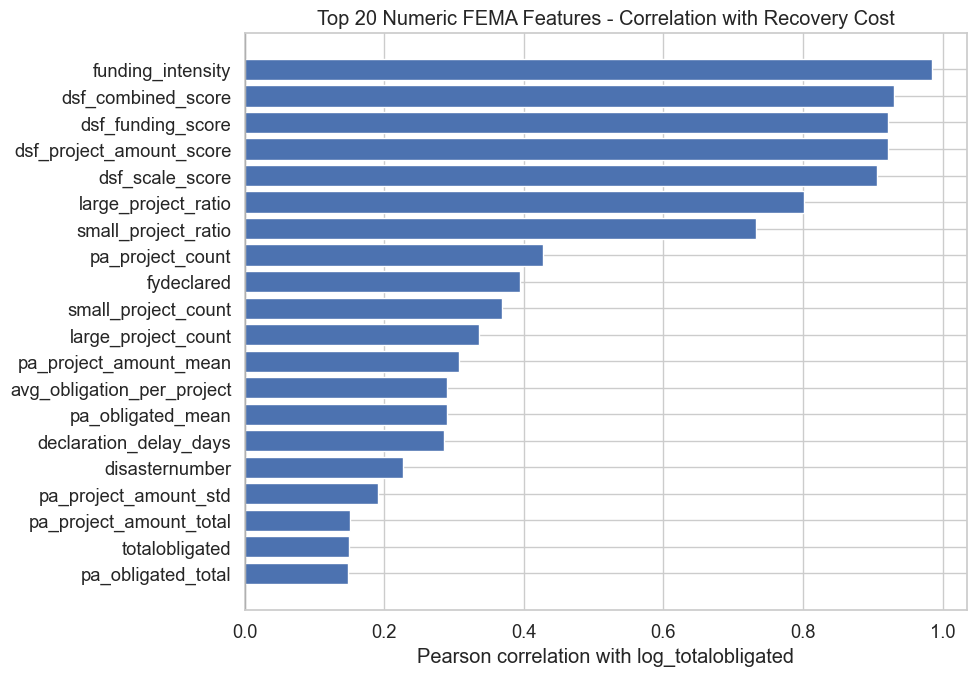

In [11]:
# step 8a - plot matrix 

fig, ax = plt.subplots(figsize=(10, 7))

top20 = corr.head(20)

ax.barh(top20.index[::-1], top20.values[::-1])
ax.axvline(0, color="black", linewidth=0.8)

ax.set(
    title="Top 20 Numeric FEMA Features - Correlation with Recovery Cost",
    xlabel="Pearson correlation with log_totalobligated"
)

plt.tight_layout()
plt.show()

### Key Observations

 DSF-related features (`dsf_combined_score`, `dsf_funding_score`,
  `dsf_project_amount_score`, `dsf_scale_score`) show the strongest
  correlation with recovery cost.

- Project-scale features such as `pa_project_count`,
  `large_project_count`, and `small_project_count` also demonstrate
  meaningful relationships with the target.

- Temporal features including `declaration_delay_days` and
  `fyDeclared` show weaker but potentially useful predictive signals.

- Several categorical features (incident type and declaration type)
  appear to influence disaster recovery cost.

### Modelling Considerations

- Correlation does not imply causation; highly correlated features
  will be evaluated further during modelling.

- Some funding-related features may be closely related to the target
  (`totalObligated`) and will be reviewed for potential target leakage
  before final model training.

- Feature importance analysis and model-based selection will be used
  during the modelling stage to identify the most predictive features.

In [12]:
print(features_fema.columns.tolist())

['disasternumber', 'state', 'declarationtype', 'incidenttype', 'fydeclared', 'designatedarea', 'declarationdate', 'incidentbegindate', 'incidentenddate', 'disaster_duration_days', 'declaration_delay_days', 'declaration_year', 'declaration_month', 'declaration_quarter', 'declaration_season', 'pa_project_count', 'pa_project_amount_total', 'pa_project_amount_mean', 'pa_project_amount_median', 'pa_project_amount_max', 'pa_project_amount_std', 'pa_obligated_total', 'pa_obligated_mean', 'pa_obligated_max', 'large_project_count', 'small_project_count', 'avg_obligation_per_project', 'funding_intensity', 'large_project_ratio', 'small_project_ratio', 'dsf_scale_score', 'dsf_project_amount_score', 'dsf_funding_score', 'dsf_combined_score', 'totalobligated', 'log_totalobligated']


#### Step 9 - Save Modelling Dataset


In [13]:

# Drop raw date columns before modelling
features_fema = features_fema.drop(columns=[
    "declarationdate",
    "incidentbegindate",
    "incidentenddate",
    "paloaddate",
    "ialoaddate"

], errors="ignore")


In [14]:
# step 9b -  save model

out_path = os.path.join(DATA_PROCESSED, "features_fema.csv")

features_fema.to_csv(out_path, index=False)

print("Saved unencoded features to:", out_path)
print("Shape:", features_fema.shape)
print("Categorical columns:")
print(features_fema.select_dtypes(include=["object"]).columns.tolist())

Saved unencoded features to: ..\data\processed\features_fema.csv
Shape: (5184, 33)
Categorical columns:
['state', 'declarationtype', 'incidenttype', 'designatedarea', 'declaration_season']
